,Değişken Grubu,Feature Selection Kararı
0,toplam_karbon_kgCO2e,Hedef değişken olarak belirlendi ve modelden ç...
1,batch_id,Model dışında bırakıldı
2,Scope emisyon değişkenleri,Model dışında bırakıldı
3,Üretim ve kaynak kullanımı değişkenleri,Model girdisi olarak korundu
4,Taşıma ve lojistik değişkenleri,Model girdisi olarak korundu
5,Atık ve atık su değişkenleri,Model girdisi olarak korundu
6,Tedavi değişkenleri,Model girdisi olarak korundu
7,Kategorik değişkenler,One-hot encoding ile dönüştürüldü


Toplam gözlem : 1000
Normal        : 950 (95.0%)
Aykırı        : 50 (5.0%)


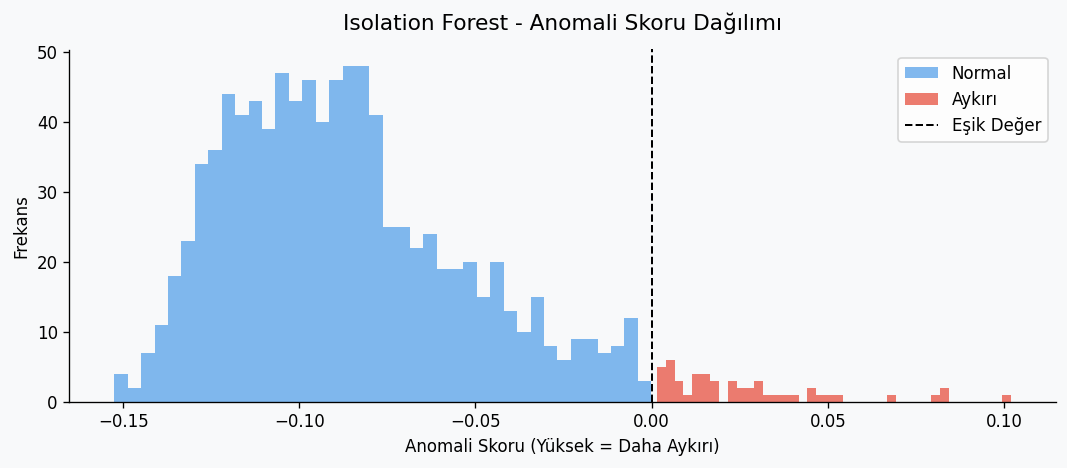

,Değişken,Normal Ortalama,Uç Aday Ortalama,Normal Medyan,Uç Aday Medyan,Normal Maksimum,Uç Aday Maksimum
0,toplam_karbon_kgCO2e,2721.75,8990.83,2041.68,9732.60,12574.60,15544.35
1,parti_buyuklugu,1095.09,1790.18,1098.00,1807.00,1999.00,2000.00
2,elektrik_kwh,785.73,1172.15,758.65,1151.60,1686.40,1663.50
3,hammadde_mesafe_km,2469.83,4522.26,1387.00,5498.00,7997.00,7913.00
4,tekstil_atik_kg,38.45,103.24,31.10,102.95,159.70,171.00
5,atiksu_lt,53255.17,113930.08,50490.00,113350.00,143252.00,177139.00
6,hammadde_ton,0.95,2.45,0.79,2.53,3.14,3.27
7,dogalgaz_m3,80.58,132.73,72.85,134.35,241.00,227.20


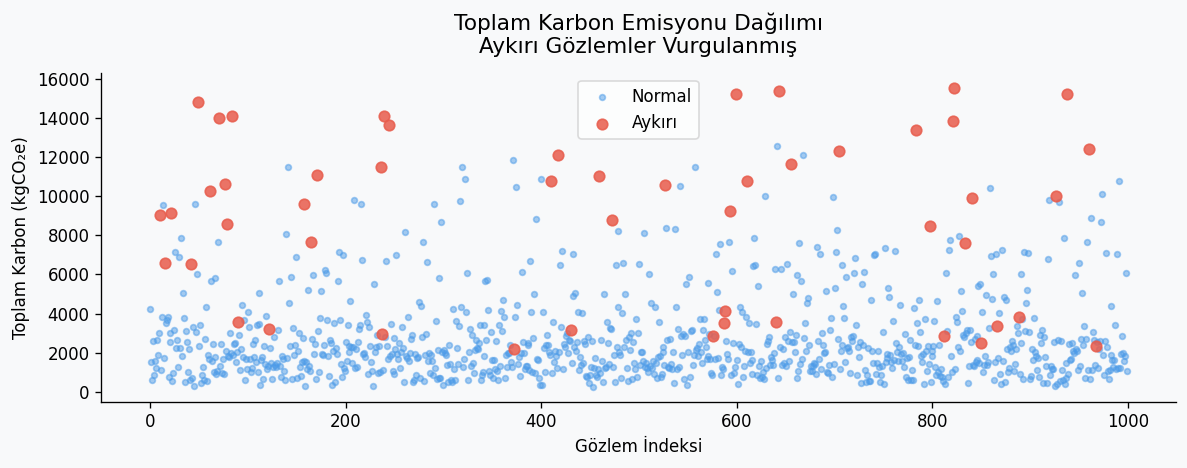

,batch_id,urun_tipi,kumas_tipi,parti_buyuklugu,ef_elektrik,hammadde_mesafe_km,tasima_modu,hammadde_ton,scope3_tasima_kgCO2e,scope3_kgCO2e,toplam_karbon_kgCO2e
22,BTH-0023,pantolon,viskon,1756,0.4138,3295,hava,2.805,5563.97,8348.27,9130.25
121,BTH-0122,tisort,keten,413,0.0747,5797,hava,0.294,1026.00,1227.27,1321.59
236,BTH-0237,pantolon,viskon,1699,0.0619,5346,hava,2.594,8348.25,11116.36,11482.47
317,BTH-0318,pantolon,pamuk_polyester,1877,0.0540,4310,hava,2.923,7584.07,9473.26,9775.18
643,BTH-0644,pantolon,polyester_100,1661,0.4740,7913,hava,2.546,12128.19,14220.62,15372.77


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})

DATA_PATH = "tekstil_karbon_datasetM.csv"
RENK_NORMAL = "#4C9BE8"
RENK_AYKIRI = "#E85C4C"
RENK_ARKA = "#F8F9FA"


def feature_selection_akisi(data_path):
    df_feature = pd.read_csv(data_path, encoding="utf-8-sig")

    target_col = "toplam_karbon_kgCO2e"

    if target_col not in df_feature.columns:
        raise ValueError(f"Hedef değişken olan {target_col} veri setinde bulunamadı.")

    id_cols = [
        "batch_id"
    ]

    leakage_cols = [
        "scope1_kgCO2e",
        "scope2_kgCO2e",
        "scope3_tasima_kgCO2e",
        "scope3_atik_kgCO2e",
        "scope3_atiksu_kgCO2e",
        "scope3_kimyasal_kgCO2e",
        "scope3_kgCO2e"
    ]

    drop_cols = id_cols + leakage_cols + [target_col]
    drop_cols_existing = [col for col in drop_cols if col in df_feature.columns]

    X = df_feature.drop(columns=drop_cols_existing)
    y = df_feature[target_col]

    categorical_cols = [
        "urun_tipi",
        "kumas_tipi",
        "tasima_modu"
    ]

    categorical_cols_existing = [col for col in categorical_cols if col in X.columns]

    X_encoded = pd.get_dummies(
        X,
        columns=categorical_cols_existing,
        drop_first=False
    )

    df_model = pd.concat([X_encoded, y], axis=1)

    feature_selection_summary = pd.DataFrame({
        "Değişken Grubu": [
            "toplam_karbon_kgCO2e",
            "batch_id",
            "Scope emisyon değişkenleri",
            "Üretim ve kaynak kullanımı değişkenleri",
            "Taşıma ve lojistik değişkenleri",
            "Atık ve atık su değişkenleri",
            "Tedavi değişkenleri",
            "Kategorik değişkenler"
        ],
        "Feature Selection Kararı": [
            "Hedef değişken olarak belirlendi ve modelden çıkarıldı",
            "Model dışında bırakıldı",
            "Model dışında bırakıldı",
            "Model girdisi olarak korundu",
            "Model girdisi olarak korundu",
            "Model girdisi olarak korundu",
            "Model girdisi olarak korundu",
            "One-hot encoding ile dönüştürüldü"
        ]
    })

    display(feature_selection_summary)

    df_model.to_csv("modelleme_oncesi_nihai_veri_seti.csv", index=False, encoding="utf-8-sig")

    return df_model


def isolation_forest_aykiri_deger_analizi(data_path):
    df_iso = pd.read_csv(data_path, encoding="utf-8-sig")

    disla = [
        "batch_id",
        "urun_tipi",
        "kumas_tipi",
        "tasima_modu",
        "ay",
        "ef_elektrik",
        "t_yenilenebilir_enerji",
        "t_yerel_tedarik",
        "t_dusuk_em_boya",
        "t_geri_donusum_prog",
        "t_makine_modernizasyon",
        "t_parti_optimizasyon"
    ]

    sayisal_sutunlar = [
        col for col in df_iso.select_dtypes(include=[np.number]).columns
        if col not in disla
    ]

    X_iso = df_iso[sayisal_sutunlar].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_iso)

    contamination = 0.05

    iso_forest = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    tahminler = iso_forest.fit_predict(X_scaled)

    df_iso["anomali_etiketi"] = tahminler
    df_iso["anomali_skoru"] = iso_forest.decision_function(X_scaled)
    df_iso["anomali_skoru_norm"] = -df_iso["anomali_skoru"]
    df_iso["sinif"] = df_iso["anomali_etiketi"].map({
        1: "Normal",
        -1: "Aykırı"
    })

    n_toplam = len(df_iso)
    n_aykiri = (df_iso["sinif"] == "Aykırı").sum()
    n_normal = (df_iso["sinif"] == "Normal").sum()
    oran_aykiri = n_aykiri / n_toplam * 100

    print(f"Toplam gözlem : {n_toplam}")
    print(f"Normal        : {n_normal} ({100 - oran_aykiri:.1f}%)")
    print(f"Aykırı        : {n_aykiri} ({oran_aykiri:.1f}%)")

    fig, ax = plt.subplots(figsize=(9, 4), facecolor=RENK_ARKA)
    ax.set_facecolor(RENK_ARKA)
    ax.hist(
        df_iso[df_iso["sinif"] == "Normal"]["anomali_skoru_norm"],
        bins=40,
        color=RENK_NORMAL,
        alpha=0.7,
        label="Normal"
    )
    ax.hist(
        df_iso[df_iso["sinif"] == "Aykırı"]["anomali_skoru_norm"],
        bins=40,
        color=RENK_AYKIRI,
        alpha=0.8,
        label="Aykırı"
    )
    esik = df_iso["anomali_skoru_norm"].quantile(1 - contamination)
    ax.axvline(
        esik,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Eşik Değer"
    )
    ax.set_title("Isolation Forest - Anomali Skoru Dağılımı", fontsize=13, pad=12)
    ax.set_xlabel("Anomali Skoru (Yüksek = Daha Aykırı)")
    ax.set_ylabel("Frekans")
    ax.legend()
    plt.tight_layout()
    plt.savefig("plot2_anomali_skoru_dagilimi.png", bbox_inches="tight")
    plt.show()

    karsilastirma_degiskenleri = [
        "toplam_karbon_kgCO2e",
        "parti_buyuklugu",
        "elektrik_kwh",
        "hammadde_mesafe_km",
        "tekstil_atik_kg",
        "atiksu_lt",
        "hammadde_ton",
        "dogalgaz_m3"
    ]

    karsilastirma_degiskenleri = [
        col for col in karsilastirma_degiskenleri
        if col in df_iso.columns
    ]

    normal_df = df_iso[df_iso["sinif"] == "Normal"]
    aykiri_df = df_iso[df_iso["sinif"] == "Aykırı"]

    karsilastirma_tablo = pd.DataFrame({
        "Değişken": karsilastirma_degiskenleri,
        "Normal Ortalama": [normal_df[col].mean() for col in karsilastirma_degiskenleri],
        "Uç Aday Ortalama": [aykiri_df[col].mean() for col in karsilastirma_degiskenleri],
        "Normal Medyan": [normal_df[col].median() for col in karsilastirma_degiskenleri],
        "Uç Aday Medyan": [aykiri_df[col].median() for col in karsilastirma_degiskenleri],
        "Normal Maksimum": [normal_df[col].max() for col in karsilastirma_degiskenleri],
        "Uç Aday Maksimum": [aykiri_df[col].max() for col in karsilastirma_degiskenleri]
    }).round(2)

    display(karsilastirma_tablo)

    if "toplam_karbon_kgCO2e" in df_iso.columns:
        fig, ax = plt.subplots(figsize=(10, 4), facecolor=RENK_ARKA)
        ax.set_facecolor(RENK_ARKA)
        normal_df = df_iso[df_iso["sinif"] == "Normal"]
        aykiri_df = df_iso[df_iso["sinif"] == "Aykırı"]
        ax.scatter(
            normal_df.index,
            normal_df["toplam_karbon_kgCO2e"],
            color=RENK_NORMAL,
            s=12,
            alpha=0.5,
            label="Normal"
        )
        ax.scatter(
            aykiri_df.index,
            aykiri_df["toplam_karbon_kgCO2e"],
            color=RENK_AYKIRI,
            s=40,
            alpha=0.85,
            label="Aykırı",
            zorder=5
        )
        ax.set_title(
            "Toplam Karbon Emisyonu Dağılımı\nAykırı Gözlemler Vurgulanmış",
            fontsize=13,
            pad=12
        )
        ax.set_xlabel("Gözlem İndeksi")
        ax.set_ylabel("Toplam Karbon (kgCO₂e)")
        ax.legend(framealpha=0.7)
        plt.tight_layout()
        plt.savefig("plot3_toplam_karbon_aykiri_gozlemler.png", bbox_inches="tight")
        plt.show()

    secili_batch_idler = [
        "BTH-0023",
        "BTH-0122",
        "BTH-0237",
        "BTH-0318",
        "BTH-0644"
    ]

    ornek_sutunlar = [
        "batch_id",
        "urun_tipi",
        "kumas_tipi",
        "parti_buyuklugu",
        "ef_elektrik",
        "hammadde_mesafe_km",
        "tasima_modu",
        "hammadde_ton",
        "scope3_tasima_kgCO2e",
        "scope3_kgCO2e",
        "toplam_karbon_kgCO2e"
    ]

    ornek_sutunlar = [col for col in ornek_sutunlar if col in df_iso.columns]

    if "batch_id" in df_iso.columns:
        aykiri_ornek_tablo = df_iso[df_iso["batch_id"].isin(secili_batch_idler)][ornek_sutunlar].copy()
        aykiri_ornek_tablo["_sira"] = pd.Categorical(
            aykiri_ornek_tablo["batch_id"],
            categories=secili_batch_idler,
            ordered=True
        )
        aykiri_ornek_tablo = aykiri_ornek_tablo.sort_values("_sira").drop(columns=["_sira"])
        display(aykiri_ornek_tablo)

    return df_iso


df_modelleme = feature_selection_akisi(DATA_PATH)
df_aykiri_analizi = isolation_forest_aykiri_deger_analizi(DATA_PATH)